# Polynomial Regression

Polynomial Regression is a supervised learning algorithm used to model
a non-linear relationship between an input feature and a continuous
target.

Unlike simple linear regression:

y = b0 + b1x

Polynomial Regression adds powers of the feature:

y = b0 + b1x + b2x² + b3x³ + ... + bnxⁿ

Polynomial Regression is still based on Linear Regression, but the
features are transformed into polynomial features.

Example:

x → x, x², x³

These transformed features are then given to a Linear Regression model.

## Why Polynomial Regression?

Linear Regression assumes that the relationship between the feature
and target is approximately linear.

But real-world relationships may be curved.

Linear:

    /
   /
  /
 /

Polynomial:

    __
  /    \
 /      \

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

Feature:

- total_bill

Target:

- tip

We will use total_bill to predict tip.

total_bill → Polynomial Transformation → tip

In [6]:
X = df[["total_bill"]]

y = df["tip"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (244, 1)
y shape: (244,)


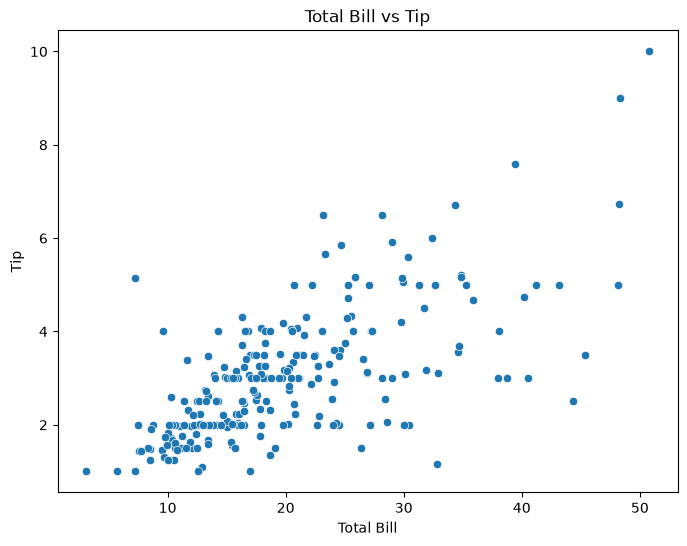

In [7]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (195, 1)
Testing: (49, 1)


## Polynomial Features

PolynomialFeatures transforms the original feature into polynomial
features.

For degree = 2:

x

becomes:

x, x²

For degree = 3:

x

becomes:

x, x², x³

For degree = 4:

x

becomes:

x, x², x³, x⁴

In [9]:
poly = PolynomialFeatures(
    degree=2
)

X_train_poly = poly.fit_transform(
    X_train
)

X_test_poly = poly.transform(
    X_test
)

print("Original shape:", X_train.shape)
print("Polynomial shape:", X_train_poly.shape)

Original shape: (195, 1)
Polynomial shape: (195, 3)


In [10]:
model = LinearRegression()

model.fit(
    X_train_poly,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0. ,0.09,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.126
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[6261.76, 28.34, 0. ]"


In [11]:
y_pred = model.predict(
    X_test_poly
)

y_pred[:10]

array([3.01733338, 1.92571395, 3.51330333, 3.65693797, 2.33250001,
       2.81990293, 3.93408644, 2.28175147, 2.50779024, 2.56742588])

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,3.017333
1,2.00,1.925714
2,2.00,3.513303
3,5.16,3.656938
4,2.00,2.332500
5,2.00,2.819903
6,2.56,3.934086
7,2.52,2.281751
8,3.23,2.507790
9,3.00,2.567426


In [13]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.6398918052296465
MSE : 0.5874658712121715
RMSE: 0.76646322234806
R²  : 0.5300165292317491


In [14]:
X_curve = np.linspace(
    X["total_bill"].min(),
    X["total_bill"].max(),
    200
).reshape(-1, 1)

X_curve_poly = poly.transform(
    X_curve
)

y_curve = model.predict(
    X_curve_poly
)

f:\Anas\DATA_SCIENCE_POTPOLIO\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


## Polynomial Regression Pipeline

Instead of manually transforming the training and testing data, we can
put PolynomialFeatures and LinearRegression inside a Pipeline.

Workflow:

Input
  ↓
PolynomialFeatures
  ↓
LinearRegression
  ↓
Prediction

In [15]:
poly_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(degree=2)
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

In [16]:
poly_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomial_features', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['total_bill']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [17]:
y_pred = poly_model.predict(
    X_test
)

y_pred[:10]

array([3.01733338, 1.92571395, 3.51330333, 3.65693797, 2.33250001,
       2.81990293, 3.93408644, 2.28175147, 2.50779024, 2.56742588])

In [18]:
r2 = r2_score(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("R² Score:", r2)
print("RMSE:", rmse)

R² Score: 0.5300165292317491
RMSE: 0.76646322234806


## Choosing the Polynomial Degree

The degree controls the complexity of the polynomial.

Degree 1:

y = b0 + b1x

Equivalent to Linear Regression.

Degree 2:

y = b0 + b1x + b2x²

Degree 3:

y = b0 + b1x + b2x² + b3x³

Higher degrees create more complex curves.

However, a very high degree can cause overfitting.

In [19]:
degrees = [1, 2, 3, 4, 5]

results = []

for degree in degrees:

    pipeline = Pipeline([
        (
            "polynomial_features",
            PolynomialFeatures(degree=degree)
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    train_r2 = pipeline.score(
        X_train,
        y_train
    )

    test_r2 = pipeline.score(
        X_test,
        y_test
    )

    results.append({
        "Degree": degree,
        "Train_R2": train_r2,
        "Test_R2": test_r2
    })

results_df = pd.DataFrame(results)

results_df

,Degree,Train_R2,Test_R2
0,1,0.430951,0.544938
1,2,0.431738,0.530017
2,3,0.453574,0.509053
3,4,0.481161,0.506605
4,5,0.503072,0.485333


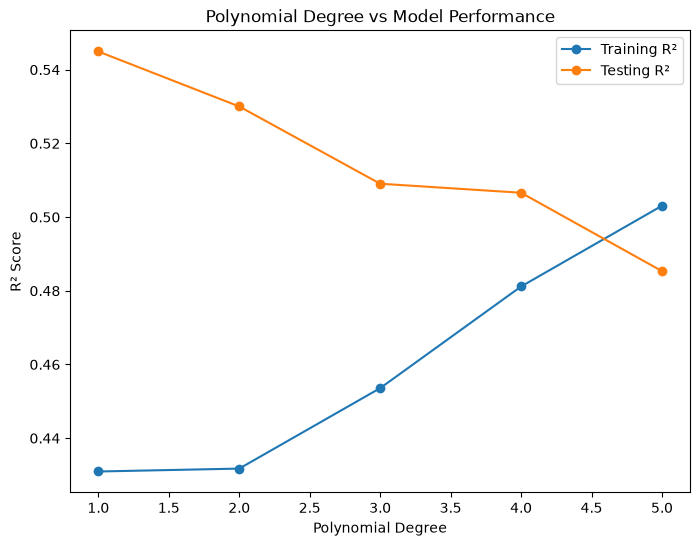

In [20]:
plt.figure(figsize=(8, 6))

plt.plot(
    results_df["Degree"],
    results_df["Train_R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    results_df["Degree"],
    results_df["Test_R2"],
    marker="o",
    label="Testing R²"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R² Score")
plt.title("Polynomial Degree vs Model Performance")

plt.legend()

plt.show()

## Underfitting

Underfitting occurs when the model is too simple to capture the
underlying pattern in the data.

Typical signs:

- Low training performance
- Low testing performance

Example:

Degree = 1

may be too simple for a strongly curved relationship.

## Overfitting

Overfitting occurs when the model becomes too complex and learns noise
from the training data.

Typical signs:

- Very high training performance
- Much lower testing performance

Very high polynomial degrees can cause overfitting.

Therefore, polynomial degree should be selected carefully.

## Linear vs Polynomial Regression

Linear Regression:

y = b0 + b1x

Produces a straight-line relationship.

Polynomial Regression:

y = b0 + b1x + b2x² + ... + bnxⁿ

Can model curved relationships.

Both use LinearRegression internally, but Polynomial Regression first
creates additional polynomial features.

In [21]:
new_bill = pd.DataFrame({
    "total_bill": [50]
})

prediction = poly_model.predict(
    new_bill
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 6.477208043296312
